In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from visual_search import VisualSearchModel
from gist import Gist
from backbone import ConvGist, AlexNet, VAE, vae_loss_fn
from torchvision.models import AlexNet_Weights
from dataset_handler import COCODatasetHandler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

coco = COCODatasetHandler("../CoCo", "train2017")
IMG_SIZE = 224
BACKBONE_WEIGHTS_PATH = "models/best_convgist_model.pth"

/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or b

Using device: cuda
loading annotations into memory...
Done (t=4.41s)
creating index...
index created!


# Prototypes

In [2]:
target_batch = coco.find_instances("stop sign", 10, max_area=3000, min_area=2000, grayscale=False)
prototype = target_batch
test_images = [target_batch[0]]

In [5]:

num_classes = 80
backbone = AlexNet(
    n_classes=num_classes,
    classifier="linear"
)
backbone.to(device)

model = VisualSearchModel(backbone, device=str(device))
print(backbone.features)

transform = AlexNet_Weights.DEFAULT.transforms()
print(transform)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU(inplace=True)
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU(inplace=True)
  (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU(inplace=True)
  (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): AdaptiveAvgPool2d(output_size=(6, 6))
  (13): Flatten(start_dim=1, end_dim=-1)
)
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [6]:
# Convert prototype list to PyTorch batch (directly from numpy, no PIL)

# Prepare batch data
batch_images = []
batch_bboxes = []

for instance in prototype:
    # Get image
    img = instance['image']
    
   
    # Store original dimensions for bbox scaling
    orig_height, orig_width = img.size
    img_tensor = transform(img)
    
    batch_images.append(img_tensor)
    
    # Transform bounding box coordinates from original to resized image space
    bbox_orig = instance['bbox_dict']
    scale_x = IMG_SIZE / orig_width
    scale_y = IMG_SIZE / orig_height
    
    bbox_transformed = {
        'x1': bbox_orig['x1'] * scale_x,
        'y1': bbox_orig['y1'] * scale_y,
        'x2': bbox_orig['x2'] * scale_x,
        'y2': bbox_orig['y2'] * scale_y
    }
    batch_bboxes.append(bbox_transformed)

# Stack into a batch tensor
prototype_batch = torch.stack(batch_images).to(device)
print(f"Prototype batch shape: {prototype_batch.shape}")
print(f"Number of bounding boxes: {len(batch_bboxes)}")
print(f"Example bbox (original → transformed): {instance['bbox_dict']} → {batch_bboxes[-1]}")

Prototype batch shape: torch.Size([10, 3, 224, 224])
Number of bounding boxes: 10
Example bbox (original → transformed): {'x1': 294.87, 'y1': 162.52, 'x2': 379.76, 'y2': 210.59} → {'x1': 137.606, 'y1': 56.882, 'x2': 177.22133333333332, 'y2': 73.70649999999999}


In [7]:
model.memorize_target_batch(prototype_batch, batch_bboxes, layer=11)

target1 = model.target_template
print(target1)

Memorized target from 10 instances
Response mean range: [0.0000, 5.5399]
Response variance range: [0.0000, 32.7307]
tensor([5.5399, 0.0488, 0.0242, 0.4143, 1.3642, 0.0000, 0.3625, 0.0337, 1.0670,
        0.0000, 0.0000, 0.0000, 0.0000, 0.8584, 0.1660, 0.4305, 0.0679, 0.0000,
        0.0921, 0.0000, 0.0000, 0.0000, 0.0000, 0.2463, 0.7845, 0.4182, 0.3919,
        0.2867, 0.0000, 0.0000, 0.0000, 0.0000, 0.1419, 0.0000, 0.0000, 0.0000,
        0.3338, 1.1759, 0.0000, 0.3371, 2.0402, 0.0093, 0.8398, 0.2075, 0.0000,
        0.0000, 0.5780, 0.0613, 0.0000, 0.0000, 0.4366, 0.0000, 0.2674, 0.0000,
        0.0000, 0.5726, 0.0615, 0.6303, 0.0157, 0.0000, 0.0000, 0.3344, 2.3343,
        0.0786, 0.0000, 0.3906, 0.0000, 0.3643, 0.0000, 0.0000, 0.1508, 0.5623,
        0.3696, 0.0000, 0.7029, 0.0000, 4.5086, 0.8147, 0.7522, 0.3988, 0.3620,
        0.7968, 1.5262, 0.1498, 0.3005, 0.0000, 0.0000, 0.1636, 0.0000, 0.0000,
        0.1221, 0.5233, 0.1767, 0.0000, 0.0000, 1.0084, 0.0000, 0.0000, 0.0000,
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


  Fixations: 3
    Fixation 1: (93, 78) - Distance: 152.9px
    Fixation 2: (85, 65) - Distance: 167.9px
    Fixation 3: (45, 66) - Distance: 185.6px
  Final distance to target: 185.6 pixels


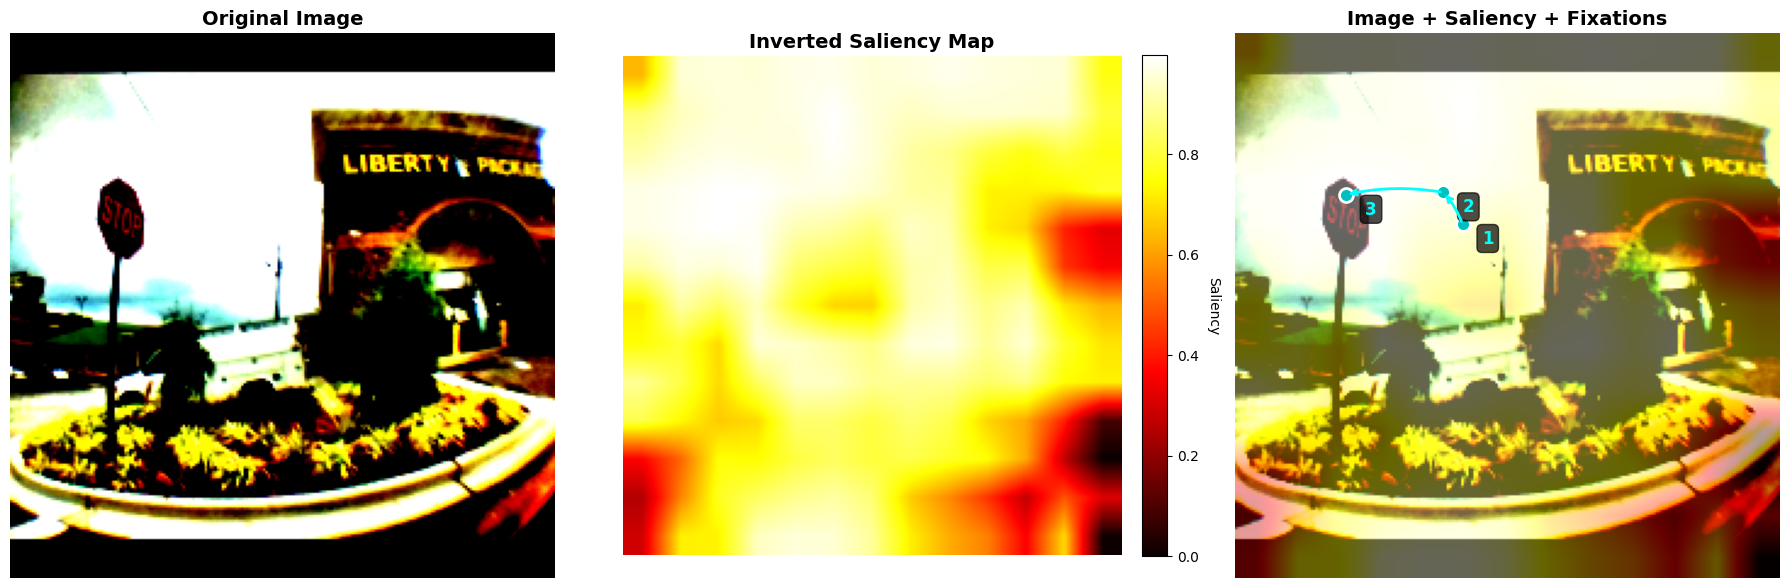

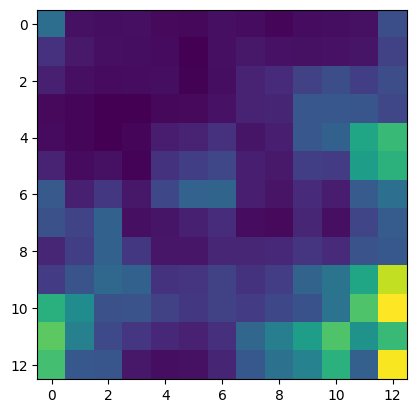

In [8]:
for idx, test_image in enumerate(test_images):
    bbox = test_image["bbox_dict"]
    target_location = (int((bbox['x1'] + bbox['x2']) / 2), int((bbox['y1'] + bbox['y2']) / 2))

    image = transform(test_image["image"])
    saliency, saliency_upsampled, fixations = model.visual_search(image.to(device))

    # Calculate performance metrics
    final_fixation = fixations[-1]
    distance_to_target = np.sqrt(
        (final_fixation[0] - target_location[0])**2 +
        (final_fixation[1] - target_location[1])**2
    )

    print(f"  Fixations: {len(fixations)}")
    for i, (x, y) in enumerate(fixations):
        dist = np.sqrt((x - target_location[0])**2 + (y - target_location[1])**2)
        print(f"    Fixation {i+1}: ({x}, {y}) - Distance: {dist:.1f}px")

    print(f"  Final distance to target: {distance_to_target:.1f} pixels")

    # Visualize results
    model.visualize_search(image, saliency_upsampled.squeeze(0), fixations)
    plt.figure()
    plt.imshow(saliency.detach().cpu().numpy().squeeze(0))
    plt.show()

In [9]:
img = prototype[0]['image']

# Store original dimensions for bbox scaling
orig_height, orig_width = img.size
img_tensor = transform(img)

# Transform bounding box coordinates from original to resized image space
bbox_orig = prototype[0]['bbox_dict']
scale_x = IMG_SIZE / orig_width
scale_y = IMG_SIZE / orig_height

bbox_transformed = {
    'x1': bbox_orig['x1'] * scale_x,
    'y1': bbox_orig['y1'] * scale_y,
    'x2': bbox_orig['x2'] * scale_x,
    'y2': bbox_orig['y2'] * scale_y
}

{'x1': 126.16, 'y1': 181.62, 'x2': 169.76, 'y2': 261.17}


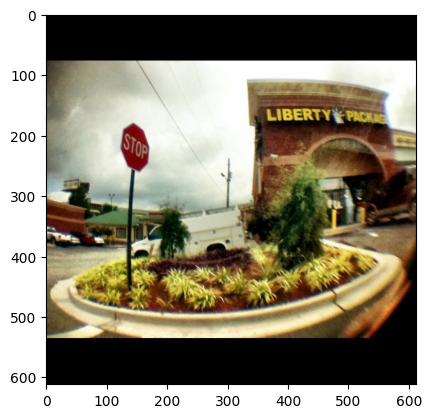

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


{'x1': 46.17620915032679, 'y1': 66.47529411764705, 'x2': 62.134379084967314, 'y2': 95.5916339869281}


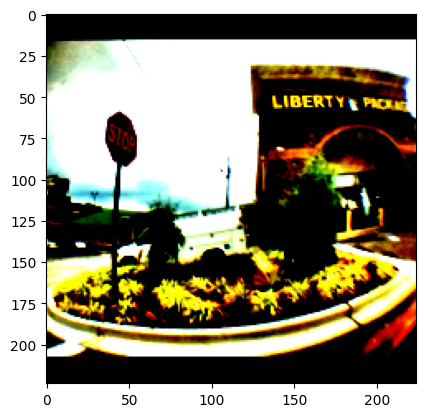

In [10]:
print(bbox_orig)

plt.figure()
plt.imshow(img)
plt.show()


print(bbox_transformed)

plt.figure()
plt.imshow(img_tensor.cpu().numpy().transpose(1,2,0))

In [11]:
model.memorize_target(img_tensor.to(device), bbox_transformed, layer=11)
target2 = model.target_template

print(target2)

tensor([ 9.8238,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.9277,  0.0000,  0.1690,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.9363,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  3.3373,  0.0000,  0.0000,  0.0000,
         3.5341,  0.0000,  7.4085,  2.0749,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  1.1024,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.3503,  0.0000,  9.6815,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.6933,  0.0000,  1.1325,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0435,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.00

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


  Fixations: 3
    Fixation 1: (74, 83) - Distance: 156.1px
    Fixation 2: (54, 82) - Distance: 167.2px
    Fixation 3: (60, 94) - Distance: 153.9px
  Final distance to target: 153.9 pixels


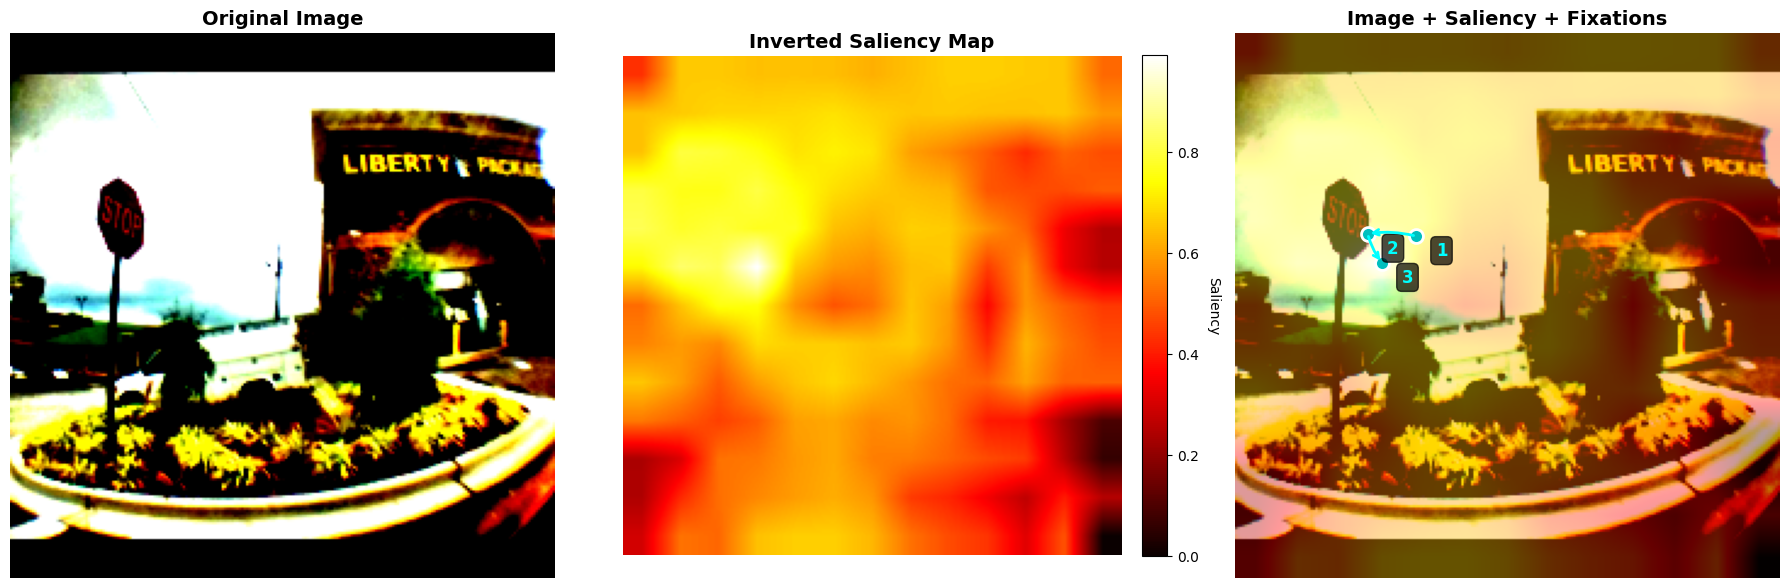

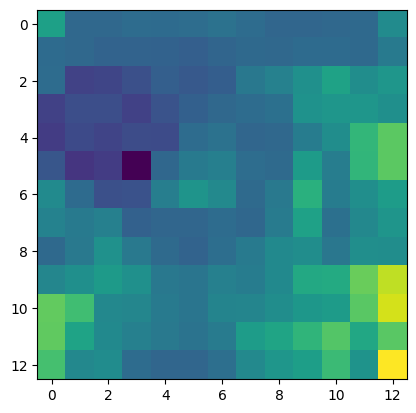

In [12]:
bbox = bbox_orig
target_location = (int((bbox['x1'] + bbox['x2']) / 2), int((bbox['y1'] + bbox['y2']) / 2))

saliency, saliency_upsampled, fixations = model.visual_search(img_tensor.to(device))

# Calculate performance metrics
final_fixation = fixations[-1]
distance_to_target = np.sqrt(
    (final_fixation[0] - target_location[0])**2 +
    (final_fixation[1] - target_location[1])**2
)

print(f"  Fixations: {len(fixations)}")
for i, (x, y) in enumerate(fixations):
    dist = np.sqrt((x - target_location[0])**2 + (y - target_location[1])**2)
    print(f"    Fixation {i+1}: ({x}, {y}) - Distance: {dist:.1f}px")

print(f"  Final distance to target: {distance_to_target:.1f} pixels")

# Visualize results
model.visualize_search(img_tensor, saliency_upsampled.squeeze(0), fixations)
plt.figure()
plt.imshow(saliency.detach().cpu().numpy().squeeze(0))
plt.show()

# Feature Space analysis

In [32]:
examples = list()
for cat in coco.get_all_categories():
    examples = examples + coco.find_instances(cat, 10, max_area=3000, min_area=2000, grayscale=False)

In [33]:
num_classes = len(coco.get_all_categories())
backbone = AlexNet(
    n_classes=num_classes,
    classifier="linear"
)
backbone.to(device)

model = VisualSearchModel(backbone, device=str(device))

transform = AlexNet_Weights.DEFAULT.transforms()

In [34]:
# Prepare batch data
batch_images = []
batch_bboxes = []

for instance in examples:
    # Get image
    img = instance['image']
    
   
    # Store original dimensions for bbox scaling
    orig_height, orig_width = img.size
    img_tensor = transform(img)
    
    batch_images.append(img_tensor)
    
    # Transform bounding box coordinates from original to resized image space
    bbox_orig = instance['bbox_dict']
    scale_x = IMG_SIZE / orig_width
    scale_y = IMG_SIZE / orig_height
    
    bbox_transformed = {
        'x1': bbox_orig['x1'] * scale_x,
        'y1': bbox_orig['y1'] * scale_y,
        'x2': bbox_orig['x2'] * scale_x,
        'y2': bbox_orig['y2'] * scale_y
    }
    batch_bboxes.append(bbox_transformed)

# Stack into a batch tensor
example_batch = torch.stack(batch_images).to(device)

In [35]:
scene_responses = model._apply_backbone(example_batch, 11)

_, _, feat_height, feat_width = scene_responses.shape
_, _, img_height, img_width = example_batch.shape

# Compute scaling from transformed image space to feature map space
scale_x = feat_width / img_width
scale_y = feat_height / img_height

# Extract response vectors for each instance at its target center
response_vectors = []

for batch_idx, bbox in enumerate(batch_bboxes):
    # Get bounding box coordinates (already in transformed image space)
    x1, y1 = bbox['x1'], bbox['y1']
    x2, y2 = bbox['x2'], bbox['y2']

    # Calculate target center in transformed image space
    center_x_img = (x1 + x2) / 2.0
    center_y_img = (y1 + y2) / 2.0

    # Convert to feature map space
    center_x_feat = center_x_img * scale_x
    center_y_feat = center_y_img * scale_y

    # Round and clamp to valid indices
    center_x_feat = int(round(center_x_feat))
    center_y_feat = int(round(center_y_feat))
    center_x_feat = max(0, min(center_x_feat, feat_width - 1))
    center_y_feat = max(0, min(center_y_feat, feat_height - 1))

    # Extract response vector at target center
    # batch_responses is (B, C, H, W), index as [batch, channels, y, x]
    response_vector = scene_responses[batch_idx, :, center_y_feat, center_x_feat]
    response_vectors.append(response_vector)

# Stack all response vectors: (num_instances, num_channels)
stacked_responses = torch.stack(response_vectors, dim=0)

In [36]:
print(stacked_responses.shape)

torch.Size([800, 256])


In [37]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Convert to numpy for sklearn
responses_np = stacked_responses.detach().cpu().numpy()

# Perform PCA
pca = PCA(n_components=2)
responses_pca = pca.fit_transform(responses_np)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA shape: {responses_pca.shape}")

PCA explained variance ratio: [0.04714065 0.04360233]
Total variance explained: 0.0907
PCA shape: (800, 2)


In [38]:
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="random")
responses_tsne = tsne.fit_transform(responses_np)

print(f"t-SNE shape: {responses_tsne.shape}")

t-SNE shape: (800, 2)


In [39]:
# Extract category labels for coloring the plots
categories = coco.get_all_categories()
unique_categories = sorted(set(categories))
category_to_idx = {cat: idx for idx, cat in enumerate(unique_categories)}
category_indices = [category_to_idx[example["category_name"]] for example in examples]

print(f"Number of unique categories: {len(unique_categories)}")

Number of unique categories: 80


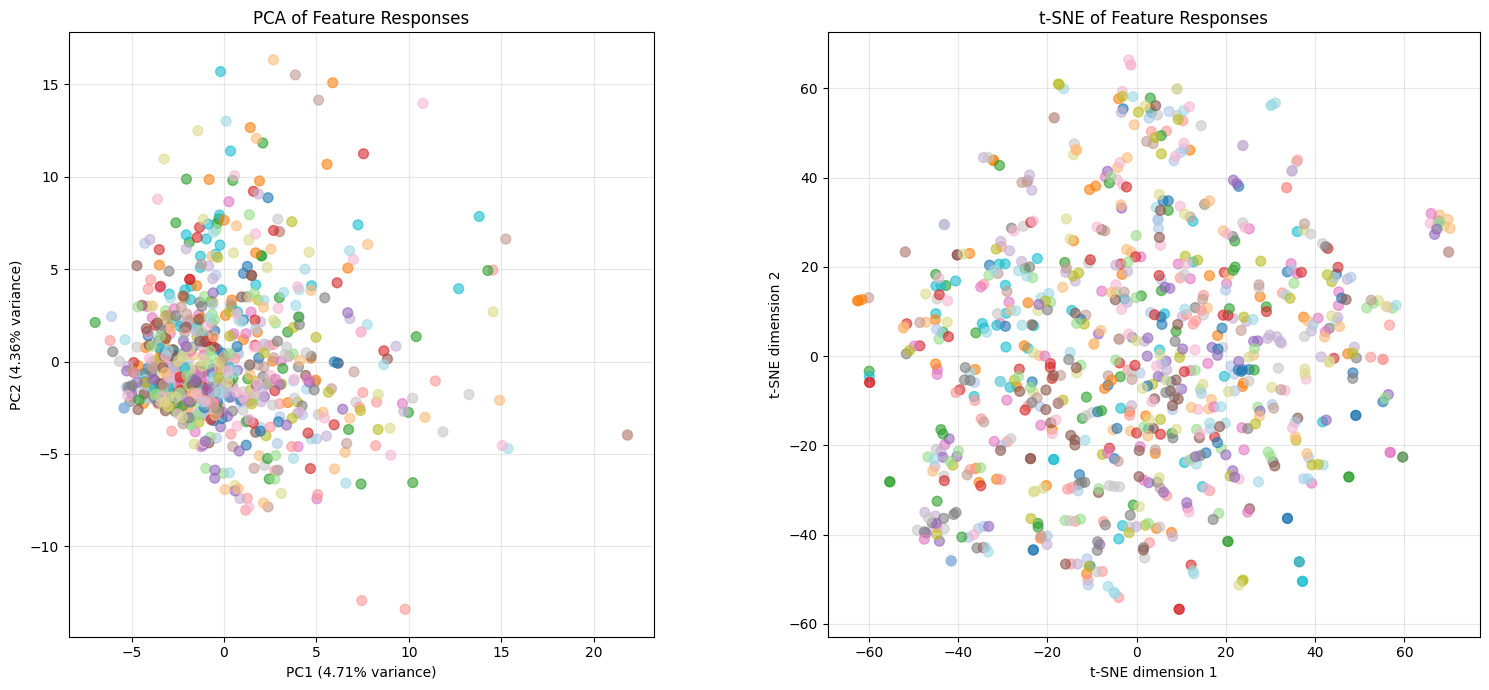

In [40]:
# Visualize PCA results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# PCA plot
scatter1 = ax1.scatter(responses_pca[:, 0], responses_pca[:, 1], 
                       c=category_indices, cmap='tab20', alpha=0.6, s=50)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax1.set_title('PCA of Feature Responses')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', 'box')

# t-SNE plot
scatter2 = ax2.scatter(responses_tsne[:, 0], responses_tsne[:, 1], 
                       c=category_indices, cmap='tab20', alpha=0.6, s=50)
ax2.set_xlabel('t-SNE dimension 1')
ax2.set_ylabel('t-SNE dimension 2')
ax2.set_title('t-SNE of Feature Responses')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()

# VAE

In [42]:
num_classes = len(coco.get_all_categories())
backbone = AlexNet(
    n_classes=num_classes,
    classifier="linear"
)
backbone.to(device)

model = VisualSearchModel(backbone, device=str(device))

transform = AlexNet_Weights.DEFAULT.transforms()

vae = VAE(256, 12)
vae.to(device)

VAE(
  (enc_fc): Linear(in_features=256, out_features=128, bias=True)
  (mu): Linear(in_features=128, out_features=12, bias=True)
  (logvar): Linear(in_features=128, out_features=12, bias=True)
  (dec_fc1): Linear(in_features=12, out_features=128, bias=True)
  (dec_fc2): Linear(in_features=128, out_features=256, bias=True)
)

In [43]:
data = list()
for cat in coco.get_all_categories():
    data = data + coco.find_instances(cat, 100, max_area=3000, min_area=2000, grayscale=False)

train = data[:int(len(data)*0.9)]
test = data[int(len(data)*0.9):]
print(len(train), len(test))

6896 767


In [44]:
# Prepare batch data
train_images = []
train_bboxes = []

for instance in train:
    # Get image
    img = instance['image']
    
   
    # Store original dimensions for bbox scaling
    orig_height, orig_width = img.size
    img_tensor = transform(img)
    
    train_images.append(img_tensor)
    
    # Transform bounding box coordinates from original to resized image space
    bbox_orig = instance['bbox_dict']
    scale_x = IMG_SIZE / orig_width
    scale_y = IMG_SIZE / orig_height
    
    bbox_transformed = {
        'x1': bbox_orig['x1'] * scale_x,
        'y1': bbox_orig['y1'] * scale_y,
        'x2': bbox_orig['x2'] * scale_x,
        'y2': bbox_orig['y2'] * scale_y
    }
    train_bboxes.append(bbox_transformed)

# Stack into a batch tensor
train_batch = torch.stack(train_images).to(device)

# Prepare batch data
test_images = []
test_bboxes = []

for instance in train:
    # Get image
    img = instance['image']
    
   
    # Store original dimensions for bbox scaling
    orig_height, orig_width = img.size
    img_tensor = transform(img)
    
    test_images.append(img_tensor)
    
    # Transform bounding box coordinates from original to resized image space
    bbox_orig = instance['bbox_dict']
    scale_x = IMG_SIZE / orig_width
    scale_y = IMG_SIZE / orig_height
    
    bbox_transformed = {
        'x1': bbox_orig['x1'] * scale_x,
        'y1': bbox_orig['y1'] * scale_y,
        'x2': bbox_orig['x2'] * scale_x,
        'y2': bbox_orig['y2'] * scale_y
    }
    test_bboxes.append(bbox_transformed)

# Stack into a batch tensor
test_batch = torch.stack(test_images).to(device)

KeyboardInterrupt: 

In [ ]:
train_responses = model._apply_backbone(train_batch, 11)

_, _, feat_height, feat_width = train_responses.shape
_, _, img_height, img_width = train_batch.shape

# Compute scaling from transformed image space to feature map space
scale_x = feat_width / img_width
scale_y = feat_height / img_height

# Extract response vectors for each instance at its target center
train_response_vectors = []

for batch_idx, bbox in enumerate(train_bboxes):
    # Get bounding box coordinates (already in transformed image space)
    x1, y1 = bbox['x1'], bbox['y1']
    x2, y2 = bbox['x2'], bbox['y2']

    # Calculate target center in transformed image space
    center_x_img = (x1 + x2) / 2.0
    center_y_img = (y1 + y2) / 2.0

    # Convert to feature map space
    center_x_feat = center_x_img * scale_x
    center_y_feat = center_y_img * scale_y

    # Round and clamp to valid indices
    center_x_feat = int(round(center_x_feat))
    center_y_feat = int(round(center_y_feat))
    center_x_feat = max(0, min(center_x_feat, feat_width - 1))
    center_y_feat = max(0, min(center_y_feat, feat_height - 1))

    # Extract response vector at target center
    # batch_responses is (B, C, H, W), index as [batch, channels, y, x]
    response_vector = train_responses[batch_idx, :, center_y_feat, center_x_feat]
    train_response_vectors.append(response_vector)

# Stack all response vectors: (num_instances, num_channels)
stacked_train_responses = torch.stack(train_response_vectors, dim=0)


test_responses = model._apply_backbone(test_batch, 11)

_, _, feat_height, feat_width = test_responses.shape
_, _, img_height, img_width = test_batch.shape

# Compute scaling from transformed image space to feature map space
scale_x = feat_width / img_width
scale_y = feat_height / img_height

In [ ]:
# Prepare test responses
test_responses = model._apply_backbone(test_batch, 11)

# Extract response vectors for test set
test_response_vectors = []

for batch_idx, bbox in enumerate(test_bboxes):
    x1, y1 = bbox['x1'], bbox['y1']
    x2, y2 = bbox['x2'], bbox['y2']

    center_x_img = (x1 + x2) / 2.0
    center_y_img = (y1 + y2) / 2.0

    center_x_feat = center_x_img * scale_x
    center_y_feat = center_y_img * scale_y

    center_x_feat = int(round(center_x_feat))
    center_y_feat = int(round(center_y_feat))
    center_x_feat = max(0, min(center_x_feat, feat_width - 1))
    center_y_feat = max(0, min(center_y_feat, feat_height - 1))

    response_vector = test_responses[batch_idx, :, center_y_feat, center_x_feat]
    test_response_vectors.append(response_vector)

stacked_test_responses = torch.stack(test_response_vectors, dim=0)

In [ ]:
# Create DataLoader for training
from torch.utils.data import TensorDataset, DataLoader

# Detach responses from computation graph since backbone is frozen
train_dataset = TensorDataset(stacked_train_responses.detach())
test_dataset = TensorDataset(stacked_test_responses.detach())

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 54
Number of test batches: 54


In [ ]:
# Training setup
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
num_epochs = 50

# Track losses
train_losses = []
test_losses = []

print("Starting VAE training...")

Starting VAE training...


In [ ]:
# Training loop
for epoch in range(num_epochs):
    # Training phase
    vae.train()
    train_loss = 0
    for batch_idx, (data,) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, _, mu, logvar = vae(data)
        
        # Compute loss
        loss = vae_loss_fn(recon_batch, data, mu, logvar, beta=1e-4)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    
    # Average training loss
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Evaluation phase
    vae.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_idx, (data,) in enumerate(test_loader):
            data = data.to(device)
            recon_batch, _, mu, logvar = vae(data)
            loss = vae_loss_fn(recon_batch, data, mu, logvar)
            test_loss += loss.item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}')

print("\nTraining completed!")

ValueError: Expected parameter loc (Tensor of shape (128, 12)) of distribution Normal(loc: torch.Size([128, 12]), scale: torch.Size([128, 12])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

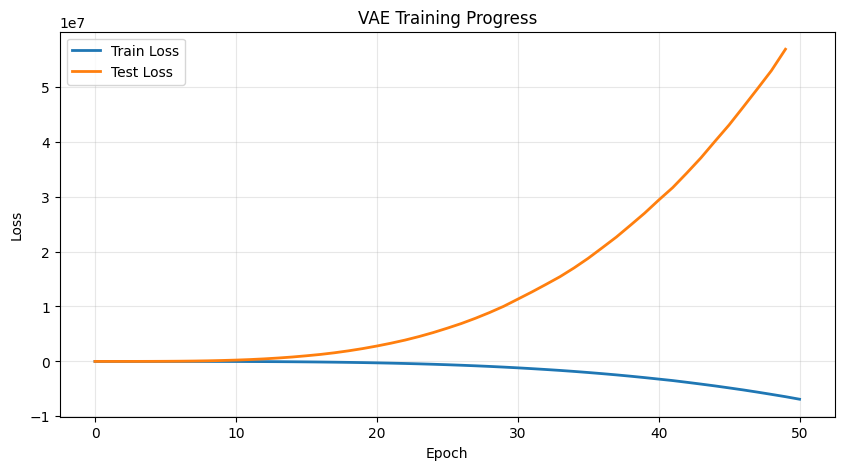

In [ ]:
# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Visualize latent space with t-SNE
vae.eval()
with torch.no_grad():
    # Encode all training data to get latent representations
    _, mu_train, _ = vae(stacked_train_responses.to(device))
    latent_train = mu_train.cpu().numpy()

print(f"Latent space shape: {latent_train.shape}")

# Apply t-SNE to latent space
tsne_latent = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
latent_tsne = tsne_latent.fit_transform(latent_train)

# Get category labels for training data
train_categories = [instance['category_name'] for instance in train]
train_category_indices = [category_to_idx[cat] for cat in train_categories]

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], 
                     c=train_category_indices, cmap='tab20', alpha=0.6, s=30)
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.title('t-SNE of VAE Latent Space')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Category')
plt.show()

In [ ]:
# Save the trained VAE model
torch.save({
    'vae_state_dict': vae.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'test_losses': test_losses,
    'latent_dim': vae.latent_dim,
    'input_dim': vae.input_dim
}, 'models/vae_alexnet_layer11.pth')

print("VAE model saved to models/vae_alexnet_layer11.pth")